<a href="https://colab.research.google.com/github/Alexandre77777/computer_math/blob/main/7.%20%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0%20SymPy/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_SymPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №7. Библиотека SymPy

In [1]:
!pip install sympy

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/6.3 MB 1.7 MB/s eta 0:00:04
   ---- ----------------------------------- 0.8/6.3 MB 1.7 MB/s eta 0:00:04
   ------ --------------------------------- 1.0/6.3 MB 1.1 MB/s eta 0:00:05
   ----------- ---------------------------- 1.8/6.3 MB 1.6 MB/s eta 0:00:03
   -------------- ------------------------- 2.4/6.3 MB 1.8 MB/s eta 0:00:03
   --------------------- ------------------ 3.4/6.3 MB 2.2 MB/s eta 0:00:02
   ----------------------- ---------------- 3.7/6.3 MB 2.2 MB/s eta 0:00:02
   ------------------------ --------------- 3.9/6.3 MB 2.2 MB/s eta 0:00:02
   -------------------------- ------------- 4.2/6.3 MB 2.0 MB/s eta 0:00:02
   ------------------------------- -----

In [2]:
import sympy as sym

### Задание №1. Создание выражения

#### Создайте выражение:

$$f = x e^{-x} + x (1-x)$$

#### Затем вычислите его для

$$x = 0, 0.1, 0.2, 0.4, 0.8$$

- Выведите выражение:

In [3]:
sp = sym                       # ниже в ноутбуке используется псевдоним sp
x = sp.Symbol('x')

f = x * sp.exp(-x) + x * (1 - x)
f

x*(1 - x) + x*exp(-x)

- Выведите ответ:

In [4]:
values = [0, 0.1, 0.2, 0.4, 0.8]
for v in values:
    print(f"f({v}) = {sp.N(f.subs(x, v), 8)}")

f(0) = 0
f(0.1) = 0.18048374
f(0.2) = 0.32374615
f(0.4) = 0.50812802
f(0.8) = 0.51946317


### Задание №2. Факторизация* полинома и нахождение его корней

#### Факторизуйте:

$$x^{4} - 6 x^{3} + x^{2} + 24 x + 16$$

#### Затем найдите его нули.

**Факторизация многочлена — представление многочлена в виде произведения многочленов меньших степеней.*

- Выведите выражение:

In [5]:
polynomial = x**4 - 6*x**3 + x**2 + 24*x + 16
polynomial

x**4 - 6*x**3 + x**2 + 24*x + 16

- Факторизуйте полином и выведите результат факторизации:

In [6]:
factored_polynomial = sp.factor(polynomial)
factored_polynomial

(x - 4)**2*(x + 1)**2

> Создадим символьное представление уравнения. В данном случае, `sp.Eq(polynomial, factored_polynomial)` создает уравнение, которое показывает равенство между исходным полиномом и его факторизованным видом.
>
>
> Это удобно использовать для демонстрации шагов решения или преобразования математических выражений.

In [6]:
equation = sp.Eq(polynomial, factored_polynomial)
equation

Eq(x**4 - 6*x**3 + x**2 + 24*x + 16, (x - 4)**2*(x + 1)**2)

- Найдите корни полинома и выведите их:

In [7]:
roots = sp.roots(polynomial, x)      # словарь {корень: кратность}
print("Корни (с кратностью):", roots)
print("Нули полинома:", sp.solve(polynomial, x))

Корни (с кратностью): {4: 2, -1: 2}
Нули полинома: [-1, 4]


### Задание №3. Интегрирование и дифференцирование

#### Интегрируйте функцию:

$$f = \sin(x) e^{-x}$$

#### Затем продифференцируйте результат, чтобы увидеть, получите ли вы исходную функцию.

- Интегрируйте функцию и выведите результат:

In [8]:
f3 = sp.sin(x) * sp.exp(-x)
integral_f = sp.integrate(f3, x)
integral_f

-exp(-x)*sin(x)/2 - exp(-x)*cos(x)/2

- Продифференцируйте результат и выведите его:

In [9]:
diff_integral_f = sp.diff(integral_f, x)
print("Совпадает с исходной функцией:", sp.simplify(diff_integral_f - f3) == 0)
diff_integral_f

Совпадает с исходной функцией: True


exp(-x)*sin(x)

In [10]:
print(f'Интеграл функции: {integral_f}')
print(f'Производная интеграла: {diff_integral_f}')

Интеграл функции: -exp(-x)*sin(x)/2 - exp(-x)*cos(x)/2
Производная интеграла: exp(-x)*sin(x)


### Задание №4. Парсинг выражения

#### Напишите функцию, которая считывает математическое выражение в виде строки (например, `"sin(2*pi*x)"`), преобразует его в выражение SymPy, а затем вычисляет его на указанном диапазоне значений.

#### Пусть ваша программа либо создает график введенной функции, либо использует входную функцию в качестве функции для подгонки набора данных с использованием curvefit.

- Подсказка: `parse_expr()` преобразует строку в выражение SymPy.

#### Пример:

In [11]:
from sympy.parsing.sympy_parser import parse_expr

In [12]:
s = "sin(2*pi*x)"
a = parse_expr(s)
a

sin(2*pi*x)

> `sympy.lambdify()` преобразует выражение SymPy в функцию, которую можно вызвать с помощью python. Вы также можете сделать ее совместимой с numpy (это означает, например, что любой `sin()` в вашем выражении SymPy будет вычислен с использованием `np.sin()`)

In [13]:
f = sp.lambdify(x, a, "numpy")

In [14]:
f(1.0)

-2.4492935982947064e-16

#### 4.1. Постройте график этой функции с помощью matplotlib:

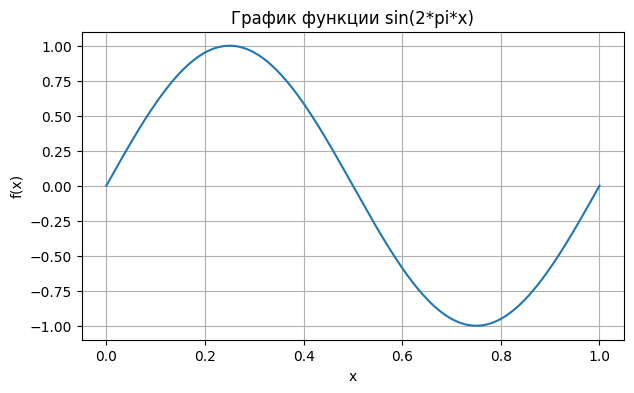

In [15]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 1, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs))
plt.title('График функции sin(2*pi*x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()

#### 4.2. Напишите функцию, которая принимает на вход четыре параметра: expr_str, x_start, x_end и num_points. Если эти параметры не предоставлены при вызове функции (т.е. они равны None), функция запрашивает соответствующие значения у пользователя. Если параметры предоставлены, функция использует их для построения графика.

  - Значения параметров:

    - `expr_str`: Это строка, которая представляет математическое выражение, которое нужно визуализировать. Например, `"sin(2*pi*x)"`. Это выражение затем преобразуется в выражение SymPy, которое можно использовать для дальнейших вычислений.

    - `x_start`: Это начальное значение `x` для диапазона значений `x`, используемых при построении графика. Например, если `x_start = 0`, то график будет начинаться с `x = 0`.

    - `x_end`: Это конечное значение `x` для диапазона значений `x`, используемых при построении графика. Например, если `x_end = 1`, то график будет заканчиваться на `x = 1`.

    - `num_points`: Это количество точек, которые будут использоваться при построении графика. Например, если `num_points = 400`, то график будет состоять из 400 точек, равномерно распределенных между `x_start` и `x_end`.

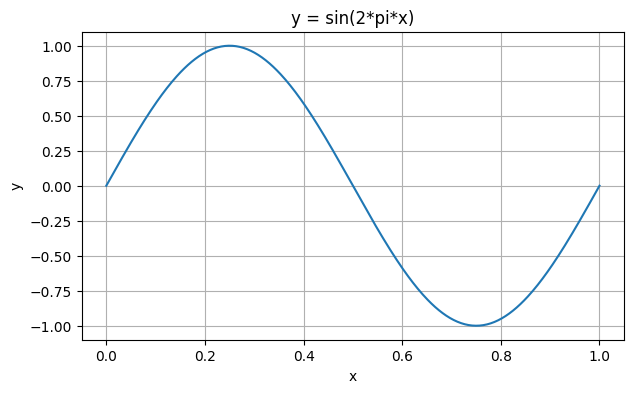

In [ ]:
from sympy.parsing.sympy_parser import parse_expr

def plot_expression(expr_str=None, x_start=None, x_end=None, num_points=None):
    """Строит график выражения, заданного строкой. Недостающие параметры запрашивает у пользователя."""
    if expr_str is None:
        expr_str = input("Введите выражение от x (например, sin(2*pi*x)): ")
    if x_start is None:
        x_start = float(input("Введите начало диапазона x_start: "))
    if x_end is None:
        x_end = float(input("Введите конец диапазона x_end: "))
    if num_points is None:
        num_points = int(input("Введите количество точек num_points: "))

    expr = parse_expr(expr_str)                                   # строка -> выражение SymPy
    func = sp.lambdify(x, expr, "numpy")                          # выражение -> функция NumPy
    xs = np.linspace(x_start, x_end, num_points)
    ys = func(xs) * np.ones_like(xs)                              # на случай константного выражения

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.title(f"y = {expr_str}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    return xs, ys

_ = plot_expression("sin(2*pi*x)", 0, 1, 400)

### Задание №5. Работа с физическими единицами измерения

SymPy позволяет работать с физическими единицами измерения. Подробнее об этом можно прочитать в документации SymPy:

http://docs.sympy.org/latest/modules/physics/units/quantities.html

Давайте попробуем это на практике. Второй закон Ньютона гласит:



$$F = ma$$



Создайте величину массы равную 1 кг и величину ускорения равную 10 м/с$^2$ , затем вычислите силу, $F$ (используя предопределенные единицы измерения kilograms, meters, seconds, newtons), и выразите результат в Ньютонах, используя метод convert_to.

In [17]:
from sympy.physics.units import kilogram, meter, second, newton, convert_to

mass = 1 * kilogram
acceleration = 10 * meter / second ** 2
force = mass * acceleration              # F = m * a

print("F =", force)
print("F в ньютонах:", convert_to(force, newton))

F = 10*kilogram*meter/second**2
F в ньютонах: 10*newton


### Задание №6. Решение обыкновенных дифференциальных уравнений

Найдите решение следующего уравнения:

$$ \frac{dy}{dt} = \cos(t) - y^{1/n}, \qquad y(0) = 2, $$

где $n > 1$ - целое число. Это небольшое изменение относительно предыдущих примеров означает, что `sympy` может представить решение только в виде степенного ряда.

#### 6.1. Найдите общее решение в виде степенного ряда для $n = 3$.

- Определите дифференциальное уравнение и отобразите его:

In [18]:
t = sp.Symbol('t')
y = sp.Function('y')
n = 3

ode = sp.Eq(y(t).diff(t), sp.cos(t) - y(t) ** sp.Rational(1, n))
ode

Eq(Derivative(y(t), t), -y(t)**(1/3) + cos(t))

- Отобразите общее решение дифференциального уравнения для $n = 3$ в виде степенного ряда:

In [19]:
# Общее решение в виде степенного ряда (первые 6 членов) для n = 3
general_solution = sp.dsolve(ode, y(t), hint='1st_power_series', n=6)
general_solution

Eq(y(t), -t**2*(1 - C1**(1/3))/(6*C1**(2/3)) + t*(1 - C1**(1/3)) + t**3*(-1 + (1 - C1**(1/3))*(1 + 2*(1 - C1**(1/3))/C1**(1/3))/(9*C1**(4/3)))/6 + t**4*((1 - C1**(1/3))*(-(1 + 2*(1 - C1**(1/3))/C1**(1/3))/C1**2 + 2*(-3 - 5*(1 - C1**(1/3))/C1**(1/3))*(1 - C1**(1/3))/C1**(7/3)) + 9/C1**(2/3))/648 + t**5*((1 - C1**(1/3))*(2*(1 - C1**(1/3))*(-2*(-3 - 5*(1 - C1**(1/3))/C1**(1/3))/C1**3 + (1 + 2*(1 - C1**(1/3))/C1**(1/3))/C1**3 + 2*(1 - C1**(1/3))*(13 + 20*(1 - C1**(1/3))/C1**(1/3))/C1**(10/3)) - (-(1 + 2*(1 - C1**(1/3))/C1**(1/3))/C1**2 + 2*(-3 - 5*(1 - C1**(1/3))/C1**(1/3))*(1 - C1**(1/3))/C1**(7/3))/C1**(2/3) - 18/C1**(5/3))/81 + 1 - 1/(9*C1**(4/3)) - 2*(1 - C1**(1/3))/(3*C1**(5/3)))/120 + C1 + O(t**6))

#### 6.2. Изучив [документацию](https://docs.sympy.org/latest/modules/solvers/ode.html) (метод `dsolve`), укажите начальное условие $y(0) = 2$ с помощью параметра `ics`. Используя данное условие, найдите решения ОДУ для $n = 3, \dots, 10$.

In [20]:
try:
    from IPython.display import display
except ImportError:
    display = print

solutions = {}
for n_val in range(3, 11):
    ode_n = sp.Eq(y(t).diff(t), sp.cos(t) - y(t) ** sp.Rational(1, n_val))
    solutions[n_val] = sp.dsolve(ode_n, y(t), ics={y(0): 2}, hint='1st_power_series', n=6)
    print(f"n = {n_val}:")
    display(solutions[n_val])

n = 3:


Eq(y(t), 2 + t*(1 - 2**(1/3)) - 2**(1/3)*t**2*(1 - 2**(1/3))/12 + t**3*(-1 + 2**(1/3)*(1 - 2**(1/3))*(2 - 2**(1/3))/36)/6 + 2**(1/3)*t**4*((1 - 2**(1/3))*(-2**(1/3)*(2 - 2**(1/3)) + 2*(-5 + 2*2**(1/3))*(1 - 2**(1/3))) + 36)/5184 + t**5*(-2**(2/3)/36 + 2**(1/3)*(1 - 2**(1/3))*(-72 + 2*(1 - 2**(1/3))*(2*(1 - 2**(1/3))*(20 - 7*2**(1/3)) + 2**(1/3)*(2 - 2**(1/3)) - 2*2**(1/3)*(-5 + 2*2**(1/3))) - 2**(1/3)*(-2**(1/3)*(2 - 2**(1/3)) + 2*(-5 + 2*2**(1/3))*(1 - 2**(1/3))))/1296 - 2**(1/3)*(1 - 2**(1/3))/6 + 1)/120 + O(t**6))

n = 4:


Eq(y(t), 2 + t*(1 - 2**(1/4)) - 2**(1/4)*t**2*(1 - 2**(1/4))/16 + t**3*(-1 + (1 - 2**(1/4))*(3*2**(1/4)*(1 - 2**(1/4)) + sqrt(2))/64)/6 + t**4*((1 - 2**(1/4))*(-2**(1/4)*(3*2**(1/4)*(1 - 2**(1/4)) + sqrt(2)) + 3*(1 - 2**(1/4))*(-3*sqrt(2) - 7*2**(1/4)*(1 - 2**(1/4)))) + 64*2**(1/4))/12288 + t**5*(-sqrt(2)/64 + (1 - 2**(1/4))*(-192*2**(1/4) - 2**(1/4)*(-2**(1/4)*(3*2**(1/4)*(1 - 2**(1/4)) + sqrt(2)) + 3*(1 - 2**(1/4))*(-3*sqrt(2) - 7*2**(1/4)*(1 - 2**(1/4)))) + 3*(1 - 2**(1/4))*((1 - 2**(1/4))*(77*2**(1/4)*(1 - 2**(1/4)) + 37*sqrt(2)) + 2**(1/4)*(3*2**(1/4)*(1 - 2**(1/4)) + sqrt(2)) - 2*2**(1/4)*(-3*sqrt(2) - 7*2**(1/4)*(1 - 2**(1/4)))))/4096 - 9*2**(1/4)*(1 - 2**(1/4))/64 + 1)/120 + O(t**6))

n = 5:


...

Eq(y(t), 2 + t*(1 - 2**(1/8)) - 2**(1/8)*t**2*(1 - 2**(1/8))/32 + t**3*(-1 + (1 - 2**(1/8))*(7*2**(1/8)*(1 - 2**(1/8)) + 2**(1/4))/256)/6 + t**4*((1 - 2**(1/8))*(-2**(1/8)*(7*2**(1/8)*(1 - 2**(1/8)) + 2**(1/4)) + 21*(1 - 2**(1/8))*(-2**(1/4) - 5*2**(1/8)*(1 - 2**(1/8)))) + 256*2**(1/8))/98304 + t**5*(-2**(1/4)/256 + (1 - 2**(1/8))*(-1792*2**(1/8) - 2**(1/8)*(-2**(1/8)*(7*2**(1/8)*(1 - 2**(1/8)) + 2**(1/4)) + 21*(1 - 2**(1/8))*(-2**(1/4) - 5*2**(1/8)*(1 - 2**(1/8)))) + 7*(1 - 2**(1/8))*(3*(1 - 2**(1/8))*(115*2**(1/8)*(1 - 2**(1/8)) + 27*2**(1/4)) + 2**(1/8)*(7*2**(1/8)*(1 - 2**(1/8)) + 2**(1/4)) - 6*2**(1/8)*(-2**(1/4) - 5*2**(1/8)*(1 - 2**(1/8)))))/65536 - 21*2**(1/8)*(1 - 2**(1/8))/256 + 1)/120 + O(t**6))

n = 9:


Eq(y(t), 2 + t*(1 - 2**(1/9)) - 2**(1/9)*t**2*(1 - 2**(1/9))/36 + t**3*(-1 + 2**(1/9)*(1 - 2**(1/9))*(8 - 7*2**(1/9))/324)/6 + 2**(1/9)*t**4*((1 - 2**(1/9))*(-2**(1/9)*(8 - 7*2**(1/9)) + 8*(-17 + 14*2**(1/9))*(1 - 2**(1/9))) + 324)/139968 + t**5*(-2**(2/9)/324 + 2**(1/9)*(1 - 2**(1/9))*(-2592 - 2**(1/9)*(-2**(1/9)*(8 - 7*2**(1/9)) + 8*(-17 + 14*2**(1/9))*(1 - 2**(1/9))) + 8*(1 - 2**(1/9))*(2*(1 - 2**(1/9))*(221 - 175*2**(1/9)) + 2**(1/9)*(8 - 7*2**(1/9)) - 2*2**(1/9)*(-17 + 14*2**(1/9))))/104976 - 2*2**(1/9)*(1 - 2**(1/9))/27 + 1)/120 + O(t**6))

n = 10:


Eq(y(t), 2 + t*(1 - 2**(1/10)) - 2**(1/10)*t**2*(1 - 2**(1/10))/40 + t**3*(-1 + (1 - 2**(1/10))*(9*2**(1/10)*(1 - 2**(1/10)) + 2**(1/5))/400)/6 + t**4*((1 - 2**(1/10))*(-2**(1/10)*(9*2**(1/10)*(1 - 2**(1/10)) + 2**(1/5)) + 9*(1 - 2**(1/10))*(-3*2**(1/5) - 19*2**(1/10)*(1 - 2**(1/10)))) + 400*2**(1/10))/192000 + t**5*(-2**(1/5)/400 + (1 - 2**(1/10))*(-3600*2**(1/10) - 2**(1/10)*(-2**(1/10)*(9*2**(1/10)*(1 - 2**(1/10)) + 2**(1/5)) + 9*(1 - 2**(1/10))*(-3*2**(1/5) - 19*2**(1/10)*(1 - 2**(1/10)))) + 9*(1 - 2**(1/10))*((1 - 2**(1/10))*(551*2**(1/10)*(1 - 2**(1/10)) + 103*2**(1/5)) + 2**(1/10)*(9*2**(1/10)*(1 - 2**(1/10)) + 2**(1/5)) - 2*2**(1/10)*(-3*2**(1/5) - 19*2**(1/10)*(1 - 2**(1/10)))))/160000 - 27*2**(1/10)*(1 - 2**(1/10))/400 + 1)/120 + O(t**6))

#### 6.3. Постройте график каждого из этих решений для $t \in [0, 1]$:

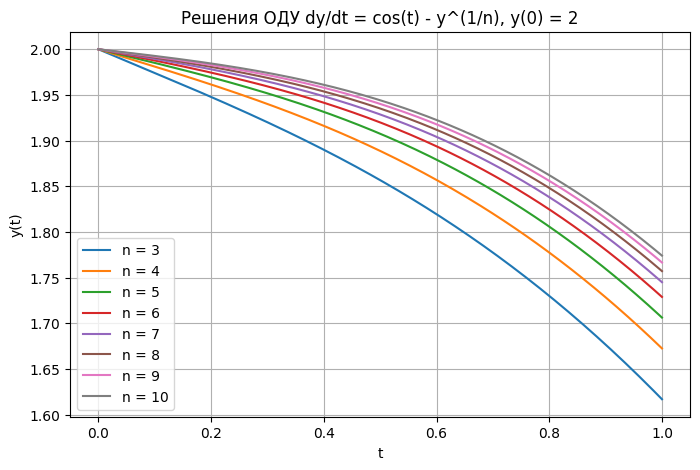

In [21]:
import numpy as np
import matplotlib.pyplot as plt

ts = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 5))
for n_val, sol in solutions.items():
    # rhs - степенной ряд; убираем член O(t**6) и переводим в функцию NumPy
    func = sp.lambdify(t, sol.rhs.removeO(), 'numpy')
    plt.plot(ts, func(ts) * np.ones_like(ts), label=f'n = {n_val}')
plt.title('Решения ОДУ dy/dt = cos(t) - y^(1/n), y(0) = 2')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()